# PART 1

Haikal Ali_1103223071_TK46GAB

# Exploratory Data Analysis


## 1. Pengantar Exploratory Data Analysis

Exploratory Data Analysis (EDA) adalah langkah awal dalam proyek data science untuk memahami data sebelum melakukan analisis lanjutan atau pemodelan.

John W. Tukey memperkenalkan pendekatan EDA melalui penggunaan ringkasan statistik dan visualisasi sederhana seperti boxplot dan scatterplot. Inti EDA adalah melihat data secara langsung agar pola, distribusi, outlier, dan hubungan antarvariabel dapat dipahami lebih awal.

## 2. Elemen Data Terstruktur

Data dapat berasal dari sensor, event, teks, gambar, video, dan sumber lainnya. Banyak data mentah berbentuk tidak terstruktur, sehingga perlu diolah menjadi bentuk terstruktur agar dapat dianalisis.

Dua tipe utama data terstruktur:
- **Numeric**, yaitu data pada skala angka.
  - **Continuous**: dapat mengambil nilai apa pun dalam interval, misalnya kecepatan angin.
  - **Discrete**: hanya berupa nilai bilangan bulat, misalnya jumlah kejadian.
- **Categorical**, yaitu data yang hanya memiliki sejumlah kategori tertentu.
  - **Binary**: kategori dengan dua nilai, misalnya 0/1 atau true/false.
  - **Ordinal**: kategori yang memiliki urutan, misalnya rating 1 sampai 5.

Tipe data penting karena menentukan cara visualisasi, analisis, dan model statistik memperlakukan variabel.

## 3. Rectangular Data

Struktur data utama dalam data science biasanya berbentuk tabel dua dimensi, yaitu baris dan kolom.

Istilah penting:
- **Data frame**: struktur data berbentuk tabel.
- **Feature**: kolom atau variabel input.
- **Outcome**: variabel target atau output.
- **Record**: baris data, disebut juga observation, sample, atau instance.

Selain rectangular data, terdapat juga struktur data lain seperti time series, spatial data, dan graph/network data.

## 4. Estimates of Location

Estimates of location digunakan untuk mencari nilai tipikal atau pusat dari suatu variabel.

Beberapa ukuran lokasi:
- **Mean**: jumlah semua nilai dibagi jumlah data.
- **Weighted mean**: mean dengan bobot.
- **Median**: nilai tengah setelah data diurutkan.
- **Percentile**: nilai yang menunjukkan posisi persentase tertentu.
- **Trimmed mean**: mean setelah membuang sebagian nilai ekstrem.
- **Robust estimate**: ukuran yang tidak terlalu sensitif terhadap outlier.

Mean mudah dihitung, tetapi sensitif terhadap nilai ekstrem. Median dan trimmed mean lebih robust terhadap outlier.

### Contoh Python: Location Estimates

Kode ini membutuhkan file `state.csv` seperti pada materi.

In [11]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "state.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "offwitt0/state-of-population-and-murder-rate-by-state",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1387/933262265.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 1.42k/1.42k [00:00<00:00, 2.93MB/s]

First 5 records:         State  Population  Murder.Rate Abbreviation
0     Alabama     4779736          5.7           AL
1      Alaska      710231          5.6           AK
2     Arizona     6392017          4.7           AZ
3    Arkansas     2915918          5.6           AR
4  California    37253956          4.4           CA


In [13]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean

state = df

state['Population'].mean()

np.float64(6162876.3)

In [14]:
trim_mean(state['Population'], 0.1)

np.float64(4783697.125)

In [15]:
state['Population'].median()

4436369.5

Untuk rata-rata murder rate nasional, pembobotan perlu mempertimbangkan jumlah populasi tiap state.

In [16]:
np.average(state['Murder.Rate'], weights=state['Population'])

np.float64(4.445833981123393)

In [19]:
import wquantiles

wquantiles.median(state['Murder.Rate'], weights=state['Population'])

np.float64(4.4)

## 5. Estimates of Variability

Variability atau dispersion mengukur seberapa menyebar nilai data.

Ukuran variabilitas:
- **Deviation**: selisih antara nilai observasi dan estimasi lokasi.
- **Variance**: rata-rata kuadrat deviasi.
- **Standard deviation**: akar dari variance.
- **Mean absolute deviation**: rata-rata nilai absolut deviasi.
- **Median absolute deviation**: median dari nilai absolut deviasi terhadap median.
- **Range**: selisih nilai maksimum dan minimum.
- **Interquartile range (IQR)**: selisih percentile ke-75 dan ke-25.

Standard deviation dan variance umum digunakan, tetapi sensitif terhadap outlier. MAD dan IQR lebih robust.

### Contoh Python: Variability Estimates

Kode ini menggunakan data `state.csv`.

In [20]:
state['Population'].std()

6848235.347401142

In [21]:
state['Population'].quantile(0.75) - state['Population'].quantile(0.25)

np.float64(4847308.0)

In [22]:
from statsmodels import robust

robust.scale.mad(state['Population'])

np.float64(3849876.1459979336)

## 6. Exploring the Data Distribution

Distribusi data dapat diamati dengan:
- **Boxplot**: visualisasi berbasis percentile.
- **Frequency table**: jumlah data dalam interval tertentu.
- **Histogram**: visualisasi frequency table.
- **Density plot**: histogram yang dihaluskan menggunakan density estimate.

### Percentiles

In [23]:
state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,Murder.Rate
0.05,1.600
0.25,2.425
0.50,4.000
0.75,5.550
0.95,6.510


### Boxplot

Text(0, 0.5, 'Population (millions)')

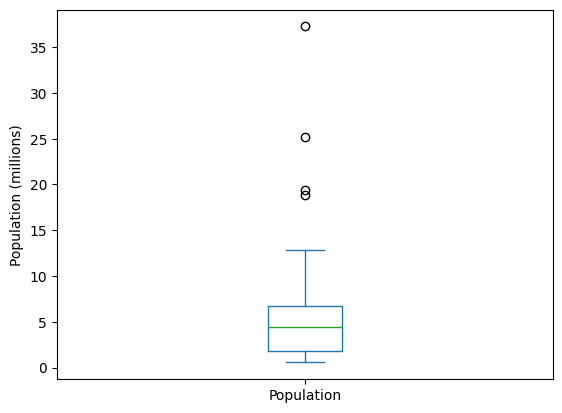

In [24]:
import matplotlib.pyplot as plt

ax = (state['Population'] / 1_000_000).plot.box()
ax.set_ylabel('Population (millions)')

### Frequency Table

In [25]:
binnedPopulation = pd.cut(state['Population'], 10)
binnedPopulation.value_counts()

,count
Population,
"(526935.67, 4232659.0]",24
"(4232659.0, 7901692.0]",14
"(7901692.0, 11570725.0]",6
"(11570725.0, 15239758.0]",2
"(15239758.0, 18908791.0]",1
"(18908791.0, 22577824.0]",1
"(22577824.0, 26246857.0]",1
"(33584923.0, 37253956.0]",1
"(26246857.0, 29915890.0]",0


### Histogram

Text(0.5, 0, 'Population (millions)')

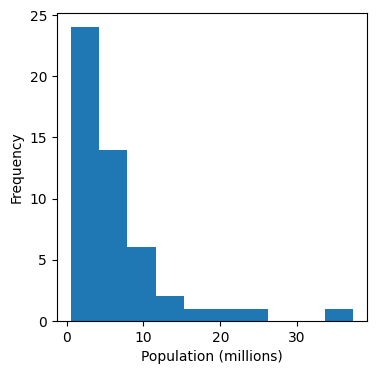

In [26]:
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Population (millions)')

### Density Plot

Text(0.5, 0, 'Murder Rate (per 100,000)')

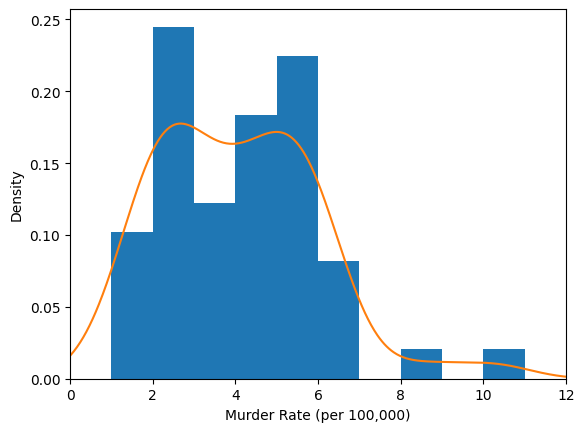

In [27]:
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0, 12], bins=range(1, 12))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')

## 7. Exploring Binary and Categorical Data

Untuk data categorical, ringkasan utama biasanya berupa proporsi atau persentase.

Istilah penting:
- **Mode**: kategori atau nilai yang paling sering muncul.
- **Expected value**: rata-rata berbobot berdasarkan probabilitas.
- **Bar chart**: frekuensi atau proporsi kategori dalam bentuk bar.
- **Pie chart**: frekuensi atau proporsi kategori dalam bentuk irisan lingkaran.

Bar chart lebih umum dan lebih informatif dibanding pie chart untuk banyak kasus.

### Contoh Python: Bar Chart

Kode ini membutuhkan data `dfw` seperti pada materi.

In [29]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "dfw_airline.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "robstepanyan/percentage-of-delays-by-cause-at-dfw",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1387/2896706333.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 90.0/90.0 [00:00<00:00, 80.8kB/s]

First 5 records:     Carrier      ATC   Weather  Security    Inbound
0  64263.16  84856.5  11235.42    343.15  118427.82


In [30]:
dfw = df

Text(0, 0.5, 'Count')

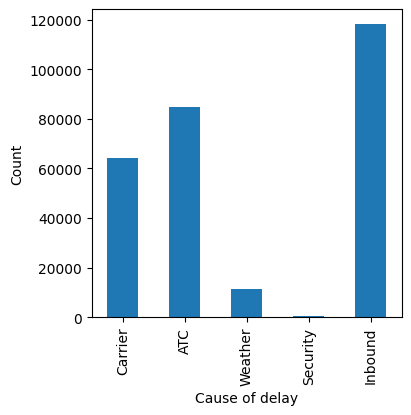

In [31]:
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Cause of delay')
ax.set_ylabel('Count')

## 8. Correlation

Correlation digunakan untuk mengukur hubungan antara dua variabel numerik.

Istilah penting:
- **Correlation coefficient**: ukuran hubungan antarvariabel numerik, bernilai antara -1 sampai +1.
- **Correlation matrix**: tabel korelasi antarvariabel.
- **Scatterplot**: plot hubungan dua variabel numerik.

Interpretasi:
- Nilai mendekati +1 berarti hubungan positif kuat.
- Nilai mendekati -1 berarti hubungan negatif kuat.
- Nilai mendekati 0 berarti tidak ada korelasi linear yang kuat.

Correlation coefficient sensitif terhadap outlier.

### Contoh Python: Correlation Matrix Heatmap

Kode ini membutuhkan data `sp500_px` dan `sp500_sym`.

In [44]:
sp500_px = pd.read_csv('/content/sp500_data.csv')
sp500_sym = pd.read_csv('/content/sp500_sectors.csv')

<Axes: >

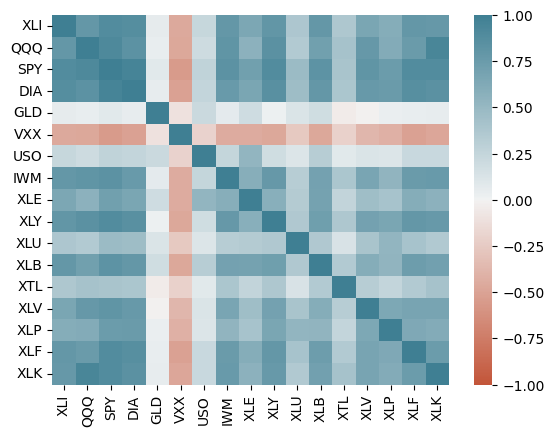

In [47]:
import seaborn as sns

etfs = sp500_px.loc[
    sp500_px['Unnamed: 0'] > '2012-07-01',
    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']
]

sns.heatmap(
    etfs.corr(),
    vmin=-1,
    vmax=1,
    cmap=sns.diverging_palette(20, 220, as_cmap=True)
)

### Contoh Python: Scatterplot

Kode ini membutuhkan data `telecom`.

In [49]:
telecom = sp500_px

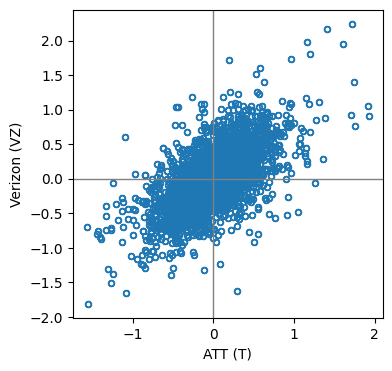

In [50]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$')
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)

## 9. Exploring Two or More Variables

Analisis multivariabel dapat memakai:
- **Contingency table** untuk dua variabel categorical.
- **Hexagonal binning** untuk dua variabel numeric dengan data sangat banyak.
- **Contour plot** untuk melihat kepadatan dua variabel numeric.
- **Violin plot** untuk numeric terhadap categorical.

## 10. Hexagonal Binning dan Contour Plot

Scatterplot kurang efektif ketika jumlah data sangat besar. Untuk data ratusan ribu atau jutaan record, hexagonal binning dan contour plot dapat membantu melihat pola hubungan dua variabel numerik.

### Filtering Data

Kode ini membutuhkan data `kc_tax`.

In [52]:
kc_tax = pd.read_csv('/content/kc_tax.csv', on_bad_lines='skip')

In [54]:
kc_tax0 = kc_tax.loc[
    (kc_tax.TaxAssessedValue < 750000) &
    (kc_tax.SqFtTotLiving > 100) &
    (kc_tax.SqFtTotLiving < 3500),
    :
]

kc_tax0.shape

(432693, 3)

### Hexagonal Binning

Text(0, 0.5, 'Tax-Assessed Value')

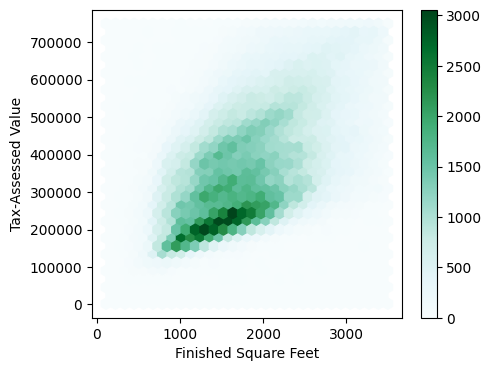

In [55]:
ax = kc_tax0.plot.hexbin(
    x='SqFtTotLiving',
    y='TaxAssessedValue',
    gridsize=30,
    sharex=False,
    figsize=(5, 4)
)

ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')

### Contour Plot

Text(0, 0.5, 'Tax-Assessed Value')

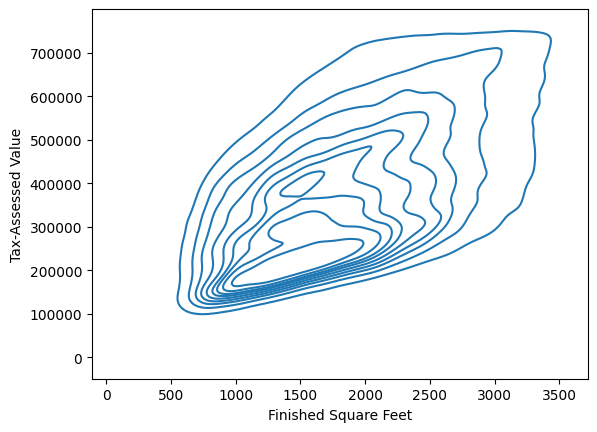

In [56]:
ax = sns.kdeplot(
    x=kc_tax0.SqFtTotLiving,
    y=kc_tax0.TaxAssessedValue
)

ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')

## 11. Two Categorical Variables

Dua variabel categorical dapat diringkas menggunakan contingency table, yaitu tabel jumlah data berdasarkan kombinasi kategori.

### Contingency Table

Kode ini membutuhkan data `lc_loans`.

In [58]:
lc_loans = pd.read_csv('/content/lc_loans.csv')

In [59]:
crosstab = lc_loans.pivot_table(
    index='grade',
    columns='status',
    aggfunc=lambda x: len(x),
    margins=True
)

df = crosstab.loc['A':'G', :].copy()

df.loc[:, 'Charged Off':'Late'] = df.loc[:, 'Charged Off':'Late'].div(
    df['All'],
    axis=0
)

df['All'] = df['All'] / sum(df['All'])

perc_crosstab = df
perc_crosstab

/tmp/ipykernel_1387/119192233.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0215478  0.04005439 0.04982834 0.06740983 0.08165728 0.1182579
 0.12619562]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Charged Off':'Late'] = df.loc[:, 'Charged Off':'Late'].div(
/tmp/ipykernel_1387/119192233.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.69045386 0.70901262 0.73570217 0.71732838 0.70793587 0.65437074
 0.61400802]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Charged Off':'Late'] = df.loc[:, 'Charged Off':'Late'].div(
/tmp/ipykernel_1387/119192233.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.28152849 0.23540077 0.19149535 0.18418891 0.1709286

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,0.021548,0.690454,0.281528,0.006470,0.160746
B,0.040054,0.709013,0.235401,0.015532,0.293529
C,0.049828,0.735702,0.191495,0.022974,0.268039
D,0.067410,0.717328,0.184189,0.031073,0.164708
E,0.081657,0.707936,0.170929,0.039478,0.077177
F,0.118258,0.654371,0.180409,0.046962,0.028614
G,0.126196,0.614008,0.198396,0.061401,0.007187


## 12. Categorical and Numeric Data

Untuk membandingkan distribusi variabel numerik berdasarkan kategori, boxplot dan violin plot dapat digunakan.

Boxplot lebih jelas untuk melihat median, IQR, dan outlier. Violin plot memperlihatkan bentuk density distribusi dengan lebih detail.

### Boxplot

Kode ini membutuhkan data `airline_stats`.

In [60]:
airline_stats = pd.read_csv('/content/airline_stats.csv')

Text(0.5, 0.98, '')

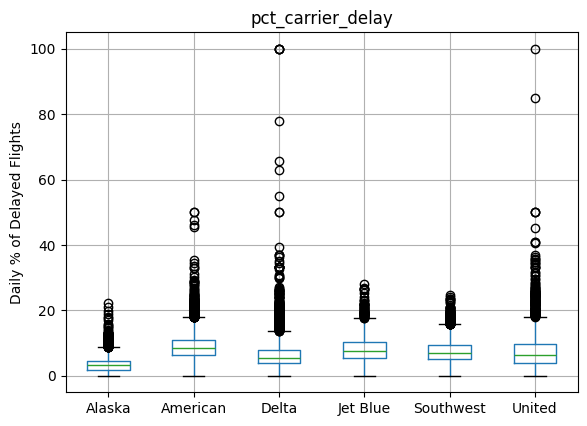

In [62]:
ax = airline_stats.boxplot(by='airline', column='pct_carrier_delay')
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')
plt.suptitle('')

### Violin Plot

Text(0, 0.5, 'Daily % of Delayed Flights')

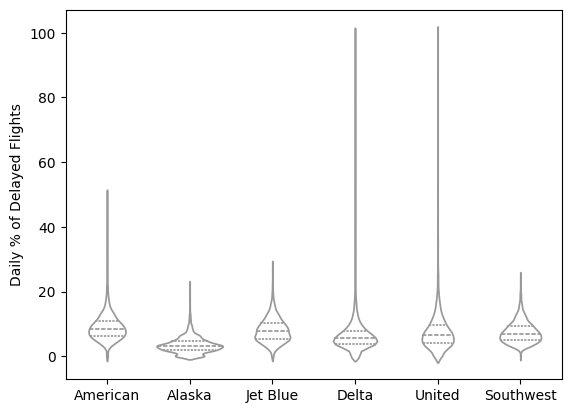

In [63]:
ax = sns.violinplot(
    x=airline_stats.airline,
    y=airline_stats.pct_carrier_delay,
    inner='quartile',
    color='white'
)

ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')

## 13. Visualizing Multiple Variables

Visualisasi dua variabel dapat diperluas dengan conditioning variable, misalnya memisahkan hubungan `SqFtTotLiving` dan `TaxAssessedValue` berdasarkan `ZipCode`.

Konsep ini disebut faceting, yaitu membuat beberapa plot kecil berdasarkan kategori tertentu.

### Faceted Hexbin Plot

Kode ini membutuhkan data `kc_tax0`.

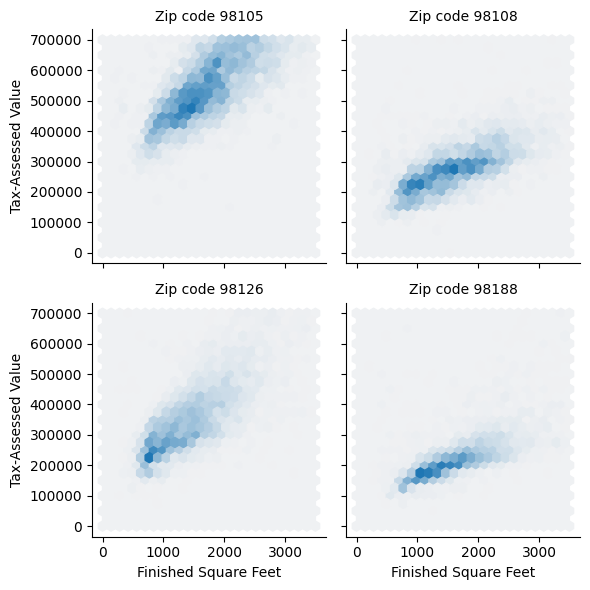

In [64]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes), :]

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)

g.map(
    hexbin,
    'SqFtTotLiving',
    'TaxAssessedValue',
    extent=[0, 3500, 0, 700000]
)

g.set_axis_labels('Finished Square Feet', 'Tax-Assessed Value')
g.set_titles('Zip code {col_name:.0f}')

## 14. Ringkasan

EDA adalah fondasi penting dalam data science. Tujuannya adalah melihat, merangkum, dan memvisualisasikan data sebelum membuat model.

Poin utama:
- Data perlu dipahami berdasarkan tipe: numeric, categorical, binary, ordinal.
- Rectangular data adalah bentuk utama untuk analisis dan pemodelan.
- Location estimate seperti mean, median, dan trimmed mean membantu melihat nilai pusat.
- Variability estimate seperti standard deviation, MAD, dan IQR membantu melihat sebaran data.
- Histogram, density plot, dan boxplot membantu memahami distribusi.
- Bar chart dan contingency table digunakan untuk categorical data.
- Correlation dan scatterplot digunakan untuk melihat hubungan dua variabel numeric.
- Hexbin, contour, violin plot, dan faceting membantu mengeksplorasi hubungan yang lebih kompleks.